In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.metrics import classification_report

In [4]:
df = pd.read_csv("emotion6.emotions.csv")

In [5]:
df.shape

(1980, 9)

In [6]:
df.columns

Index(['img_id', 'img_amusement', 'img_awe', 'img_contentment',
       'img_excitement', 'img_anger', 'img_disgust', 'img_fear',
       'img_sadness'],
      dtype='object')

In [7]:
df.head(5)

,img_id,img_amusement,img_awe,img_contentment,img_excitement,img_anger,img_disgust,img_fear,img_sadness
0,anger.154,0.006206,0.045369,0.036360,0.246629,0.075254,0.004119,0.512813,0.073249
1,anger.1,0.008310,0.061734,0.016367,0.050843,0.121426,0.006986,0.501763,0.232571
2,anger.155,0.000730,0.016894,0.000643,0.000310,0.952117,0.007543,0.019964,0.001799
3,anger.10,0.000507,0.000080,0.000405,0.005145,0.986959,0.000991,0.004182,0.001732
4,anger.156,0.018760,0.175910,0.010343,0.013993,0.097712,0.000882,0.172623,0.509775


In [21]:
by_img_df = df[["img_id"]].copy()
by_img_df["label"] = df["img_id"].apply(lambda s: s.partition(".")[0])
by_img_df["indicator"] = 1
labled_df = by_img_df.pivot(index="img_id", columns="label", values="indicator").fillna(0)
labled_df.columns = ["label_" + c for c in labled_df.columns]
labled_df.head()

,label_anger,label_disgust,label_fear,label_joy,label_sadness,label_surprise
img_id,,,,,,
anger.1,1.0,0.0,0.0,0.0,0.0,0.0
anger.10,1.0,0.0,0.0,0.0,0.0,0.0
anger.100,1.0,0.0,0.0,0.0,0.0,0.0
anger.101,1.0,0.0,0.0,0.0,0.0,0.0
anger.102,1.0,0.0,0.0,0.0,0.0,0.0


In [24]:
df = df.set_index("img_id").join(labled_df).reset_index()

In [35]:
df

,img_id,img_amusement,img_awe,img_contentment,img_excitement,img_anger,img_disgust,img_fear,img_sadness,label_anger,label_disgust,label_fear,label_joy,label_sadness,label_surprise,txt_label,img_label
0,anger.154,0.006206,0.045369,0.036360,0.246629,0.075254,0.004119,0.512813,0.073249,1.0,0.0,0.0,0.0,0.0,0.0,anger,fear
1,anger.1,0.008310,0.061734,0.016367,0.050843,0.121426,0.006986,0.501763,0.232571,1.0,0.0,0.0,0.0,0.0,0.0,anger,fear
2,anger.155,0.000730,0.016894,0.000643,0.000310,0.952117,0.007543,0.019964,0.001799,1.0,0.0,0.0,0.0,0.0,0.0,anger,anger
3,anger.10,0.000507,0.000080,0.000405,0.005145,0.986959,0.000991,0.004182,0.001732,1.0,0.0,0.0,0.0,0.0,0.0,anger,anger
4,anger.156,0.018760,0.175910,0.010343,0.013993,0.097712,0.000882,0.172623,0.509775,1.0,0.0,0.0,0.0,0.0,0.0,anger,sadness
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975,surprise.95,0.005753,0.967619,0.018548,0.000493,0.003699,0.000071,0.001280,0.002536,0.0,0.0,0.0,0.0,0.0,1.0,surprise,awe
1976,surprise.96,0.096840,0.073612,0.500713,0.035487,0.224487,0.008779,0.022904,0.037180,0.0,0.0,0.0,0.0,0.0,1.0,surprise,contentment
1977,surprise.97,0.064848,0.220092,0.103053,0.431015,0.130305,0.009052,0.013062,0.028572,0.0,0.0,0.0,0.0,0.0,1.0,surprise,excitement
1978,surprise.98,0.040370,0.676550,0.091709,0.112338,0.032297,0.010825,0.013217,0.022694,0.0,0.0,0.0,0.0,0.0,1.0,surprise,awe


In [26]:
dup_df = df.drop(columns=[
    "img_id",
])
img_cs = [c for c in dup_df.columns if c.startswith("img_")]
pmt_cs = [c for c in dup_df.columns if c.startswith("label_")]

In [27]:
pmt_cs

['label_anger',
 'label_disgust',
 'label_fear',
 'label_joy',
 'label_sadness',
 'label_surprise']

In [28]:
def generate_text_label(row):
    argmax = np.argmax(row[pmt_cs])
    return pmt_cs[argmax].partition("_")[-1]

def generate_image_label(row):
    argmax = np.argmax(row[img_cs])
    return img_cs[argmax].partition("_")[-1]

In [29]:
df["txt_label"] = df.apply(generate_text_label, axis=1)
df["img_label"] = df.apply(generate_image_label, axis=1)

In [30]:
df["txt_label"].value_counts()

txt_label
anger       330
disgust     330
fear        330
joy         330
sadness     330
surprise    330
Name: count, dtype: int64

In [31]:
df["img_label"].value_counts()

img_label
awe            467
fear           456
sadness        270
disgust        259
contentment    196
amusement      174
anger           84
excitement      74
Name: count, dtype: int64

In [32]:
df[["img_label", "txt_label"]]

,img_label,txt_label
0,fear,anger
1,fear,anger
2,anger,anger
3,anger,anger
4,sadness,anger
...,...,...
1975,awe,surprise
1976,contentment,surprise
1977,excitement,surprise
1978,awe,surprise


In [38]:
tdf = df.copy()
tdf["mark"] = 1
pivot_txt = tdf[["mark","img_id", "txt_label"]].pivot(columns="txt_label", index="img_id", values="mark").fillna(0)
pivot_img = tdf[["mark","img_id", "img_label"]].pivot(columns="img_label", index="img_id", values="mark").fillna(0)

pivot_txt.columns = [c+"_txt" for c in pivot_txt.columns]
pivot_img.columns = [c+"_img" for c in pivot_img.columns]

In [39]:
joined_df = pivot_img.join(pivot_txt, lsuffix="_img", rsuffix="_txt")
joined_df

,amusement_img,anger_img,awe_img,contentment_img,disgust_img,excitement_img,fear_img,sadness_img,anger_txt,disgust_txt,fear_txt,joy_txt,sadness_txt,surprise_txt
img_id,,,,,,,,,,,,,,
anger.1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
anger.10,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
anger.100,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
anger.101,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
anger.102,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
surprise.95,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
surprise.96,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
surprise.97,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [40]:
corr_df = joined_df.corr()
e_cs = sorted(corr_df.columns)
rel_corr_df = corr_df.loc[[c for c in e_cs if "_img" in c]][[c for c in e_cs if "_txt" in c]]
rel_corr_df

,anger_txt,disgust_txt,fear_txt,joy_txt,sadness_txt,surprise_txt
amusement_img,-0.095733,-0.019147,-0.062227,0.258480,-0.110093,2.871997e-02
anger_img,0.154645,-0.067237,0.047066,-0.087408,-0.047066,-4.730811e-17
awe_img,0.192063,-0.213345,-0.095234,0.016493,-0.136732,2.367539e-01
contentment_img,-0.121007,-0.093780,-0.125544,0.332769,-0.003025,1.058809e-02
disgust_img,-0.153395,0.630325,-0.093109,-0.161433,-0.145356,-7.703224e-02
excitement_img,0.011908,-0.073829,-0.073829,0.054777,-0.038106,1.190797e-01
fear_img,0.012875,-0.045063,0.344409,-0.186689,0.028969,-1.545015e-01
sadness_img,-0.015796,-0.122419,-0.039490,-0.114521,0.418593,-1.263678e-01


In [41]:
rel_corr_df.columns


Index(['anger_txt', 'disgust_txt', 'fear_txt', 'joy_txt', 'sadness_txt',
       'surprise_txt'],
      dtype='object')

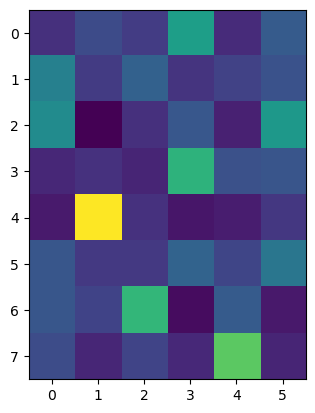

In [42]:
plt.imshow(rel_corr_df)

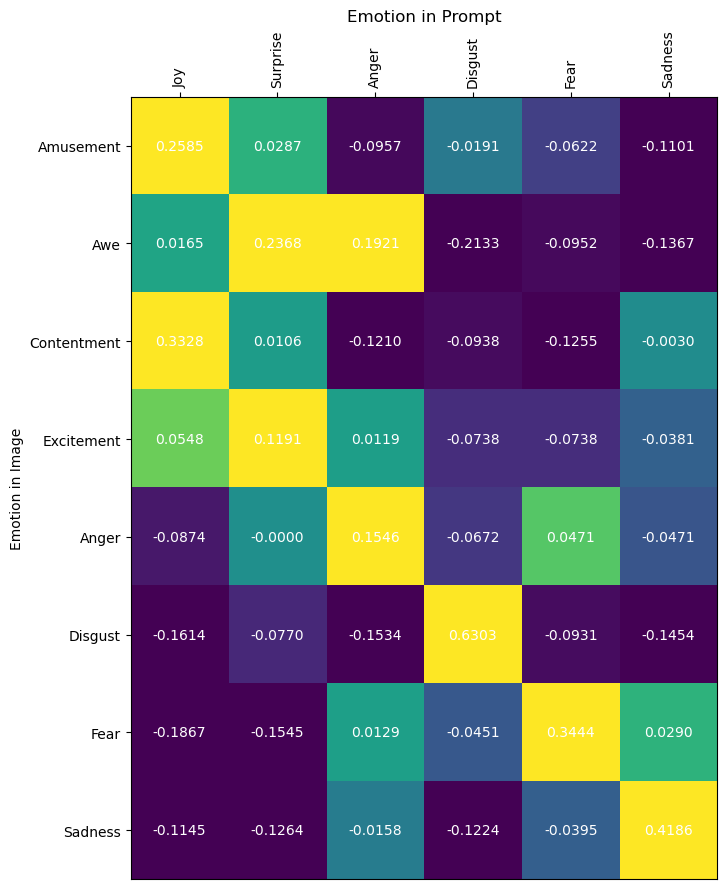

In [43]:
fig = plt.figure(figsize=(18,9))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# row_i = rel_corr_df.index
# col_j = rel_corr_df.columns

row_i = [
    'amusement_img',
    'awe_img',
    'contentment_img',
    'excitement_img',
    'anger_img',
    'disgust_img',
    'fear_img',
    'sadness_img'
]
col_j = [
    "joy_txt",
    "surprise_txt",
    "anger_txt",
    "disgust_txt",
    "fear_txt",
    "sadness_txt",
]

row_labels = [c.partition("_")[0].title() for c in row_i]
col_labels = [c.partition("_")[0].title() for c in col_j]

target_df = rel_corr_df.loc[row_i][col_j]

ax.imshow(target_df.values, cmap='viridis', vmin=-0.1, vmax=0.1)
ax.set_yticks(ticks=range(0,len(row_labels)), labels=row_labels, rotation=0)
ax.set_xticks(ticks=range(0,len(col_labels)), labels=col_labels, rotation=90)

# Loop over data dimensions and create text annotations.
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        text = ax.text(j, i, "%0.04f" % target_df.values[i, j], ha="center", va="center", color="w")

ax.set_ylabel("Emotion in Image")
ax.set_title("Emotion in Prompt")

plt.tight_layout()
plt.savefig("full_img_to_txt.emotion6.pdf", format="pdf")


In [58]:
# aligned_emotions = {
#     "amusement": "amusement",
#     "anger": "anger",
#     "disgust": "disgust",
#     "excitement": "excitement",
#     "fear": "fear",
#     "sadness": "sadness",
#     "joy": "contentment",
#     "love": "amusement",
#     "contentment": "contentment",
#     "awe": "awe",
#     "admiration": "awe",
# }

aligned_emotions = {
    # EmoSet
    "amusement": "joy",
    "awe": "surprise",
    "excitement": "joy",
    "contentment": "joy",
    "fear": "fear",
    "anger": "anger",
    "disgust": "disgust",
    "sadness": "sadness",

    # Emotion6
    "joy": "joy",
    "surprise": "surprise",

    # # GoEmotions
    # "annoyance": "anger",
    # "disapproval": "anger",
    # "nervousness": "fear",
    # "disappointment": "sadness",
    # "embarrassment": "sadness",
    # "grief": "sadness",
    # "remorse": "sadness",
    # "admiration": "joy",
    # "amusement": "joy",
    # "approval": "joy",
    # "caring": "joy",
    # "desire": "joy",
    # "excitement": "joy",
    # "gratitude": "joy",
    # "love": "joy",
    # "joy": "joy",
    # "optimism": "joy",
    # "pride": "joy",
    # "remorse": "joy",
    # "curiosity": "surprise",
    # "realization": "surprise",
    # "surprise": "surprise",
    # "confusion": "surprise",
}

e_cs = list(set(aligned_emotions.values()))
e_cs

['surprise', 'disgust', 'fear', 'sadness', 'anger', 'joy']

In [59]:
df["txt_label_aligned"] = df["txt_label"].apply(lambda s: aligned_emotions.get(s,"OTHER"))
df["img_label_aligned"] = df["img_label"].apply(lambda s: aligned_emotions.get(s,"OTHER"))


In [60]:
df["txt_label_aligned"].value_counts()

txt_label_aligned
anger       330
disgust     330
fear        330
joy         330
sadness     330
surprise    330
Name: count, dtype: int64

In [61]:
df["img_label_aligned"].value_counts()

img_label_aligned
surprise    467
fear        456
joy         444
sadness     270
disgust     259
anger        84
Name: count, dtype: int64

In [62]:
tdf = df.copy()
tdf["mark"] = 1
pivot_txt = tdf[["mark","img_id", "txt_label_aligned"]].pivot(columns="txt_label_aligned", index="img_id", values="mark").fillna(0)
pivot_img = tdf[["mark","img_id", "img_label_aligned"]].pivot(columns="img_label_aligned", index="img_id", values="mark").fillna(0)


In [63]:
joined_df = pivot_img.join(pivot_txt, lsuffix="_img", rsuffix="_txt")
joined_df

,anger_img,disgust_img,fear_img,joy_img,sadness_img,surprise_img,anger_txt,disgust_txt,fear_txt,joy_txt,sadness_txt,surprise_txt
img_id,,,,,,,,,,,,
anger.1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
anger.10,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
anger.100,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
anger.101,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
anger.102,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
surprise.95,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
surprise.96,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
surprise.97,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [64]:
corr_df = joined_df.corr()
rel_corr_df = corr_df.loc[[c+"_img" for c in e_cs]][[c+"_txt" for c in e_cs]]
rel_corr_df

,surprise_txt,disgust_txt,fear_txt,sadness_txt,anger_txt,joy_txt
surprise_img,2.367539e-01,-0.213345,-0.095234,-0.136732,0.192063,0.016493
disgust_img,-7.703224e-02,0.630325,-0.093109,-0.145356,-0.153395,-0.161433
fear_img,-1.545015e-01,-0.045063,0.344409,0.028969,0.012875,-0.186689
sadness_img,-1.263678e-01,-0.122419,-0.039490,0.418593,-0.015796,-0.114521
anger_img,-4.730811e-17,-0.067237,0.047066,-0.047066,0.154645,-0.087408
joy_img,8.123051e-02,-0.113723,-0.165710,-0.094227,-0.146215,0.438645


In [65]:
rel_corr_df.index

Index(['surprise_img', 'disgust_img', 'fear_img', 'sadness_img', 'anger_img',
       'joy_img'],
      dtype='object')

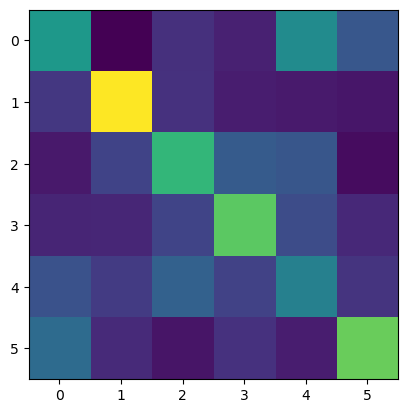

In [66]:
plt.imshow(rel_corr_df)

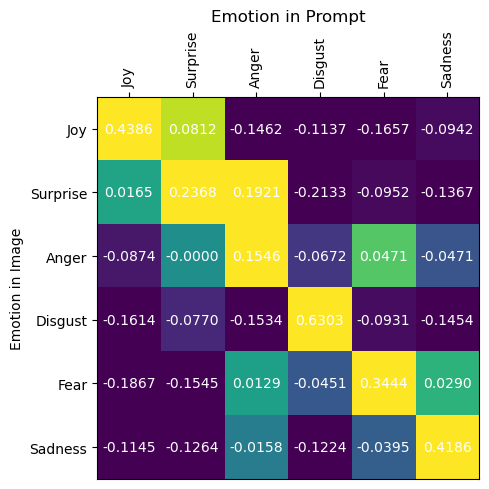

In [67]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# row_i = rel_corr_df.index
# col_j = rel_corr_df.columns

row_i = [
    'joy_img',
    'surprise_img',
    'anger_img',
    'disgust_img', 
    'fear_img', 
    'sadness_img',   
]
col_j = [
    'joy_txt',
    'surprise_txt',
    'anger_txt',
    'disgust_txt', 
    'fear_txt', 
    'sadness_txt',   
]

row_labels = [c.partition("_")[0].title() for c in row_i]
col_labels = [c.partition("_")[0].title() for c in col_j]

target_df = rel_corr_df.loc[row_i][col_j]

ax.imshow(target_df.values, cmap='viridis', vmin=-0.1, vmax=0.1)
ax.set_yticks(ticks=range(0,len(row_labels)), labels=row_labels, rotation=0)
ax.set_xticks(ticks=range(0,len(col_labels)), labels=col_labels, rotation=90)

# Loop over data dimensions and create text annotations.
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        text = ax.text(j, i, "%0.04f" % target_df.values[i, j], ha="center", va="center", color="w")

ax.set_ylabel("Emotion in Image")
ax.set_title("Emotion in Prompt")

plt.tight_layout()
plt.savefig("ekman_img_to_txt.emotion6.pdf", format="pdf")



In [68]:
rel_corr_df.max().max()

0.6303246684555773

In [69]:
np.mean([rel_corr_df.loc[row_i[i]][col_j[i]] for i in range(6)])

np.float64(0.3705617959079131)

In [70]:
print(classification_report(df["txt_label_aligned"], df["img_label_aligned"]))

              precision    recall  f1-score   support

       anger       0.44      0.11      0.18       330
     disgust       0.77      0.61      0.68       330
        fear       0.40      0.55      0.47       330
         joy       0.47      0.63      0.54       330
     sadness       0.56      0.46      0.50       330
    surprise       0.33      0.46      0.38       330

    accuracy                           0.47      1980
   macro avg       0.49      0.47      0.46      1980
weighted avg       0.49      0.47      0.46      1980



In [71]:
pos_neg_groups = {
    "anger": "NEGATIVE",
    "disgust": "NEGATIVE",
    "fear": "NEGATIVE",
    "sadness": "NEGATIVE",
    "surprise": "AMBIGUOUS",
    "joy": "POSITIVE",
}
inv_pos_neg_groups = {}
for k,v in pos_neg_groups.items():
    inv_pos_neg_groups[v] = inv_pos_neg_groups.get(v,[]) + [k]

In [72]:
df["txt_label_group"] = df["txt_label_aligned"].apply(lambda s: pos_neg_groups.get(s,"OTHER"))
df["img_label_group"] = df["img_label_aligned"].apply(lambda s: pos_neg_groups.get(s,"OTHER"))


In [73]:
df["txt_label_group"].value_counts()

txt_label_group
NEGATIVE     1320
POSITIVE      330
AMBIGUOUS     330
Name: count, dtype: int64

In [74]:
df["img_label_group"].value_counts()

img_label_group
NEGATIVE     1069
AMBIGUOUS     467
POSITIVE      444
Name: count, dtype: int64

In [75]:
tdf = df.copy()
tdf["mark"] = 1

In [77]:
pivot_txt = tdf[["mark","img_id", "txt_label_group"]].pivot(columns="txt_label_group", index="img_id", values="mark").fillna(0)
pivot_img = tdf[["mark","img_id", "img_label_group"]].pivot(columns="img_label_group", index="img_id", values="mark").fillna(0)


In [78]:
highest_agg = list(set(pos_neg_groups.values()))

joined_df = pivot_img.join(pivot_txt, lsuffix="_img", rsuffix="_txt")
corr_df = joined_df.corr()
rel_corr_df = corr_df.loc[[c+"_img" for c in highest_agg]][[c+"_txt" for c in highest_agg]]
rel_corr_df

,AMBIGUOUS_txt,NEGATIVE_txt,POSITIVE_txt
AMBIGUOUS_img,0.236754,-0.200209,0.016493
NEGATIVE_img,-0.269640,0.514472,-0.381121
POSITIVE_img,0.081231,-0.410997,0.438645


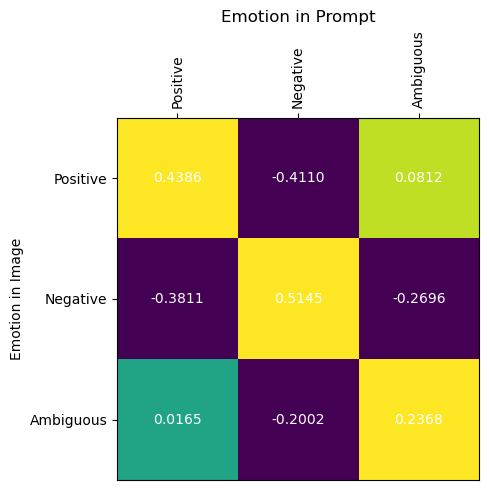

In [79]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# row_i = rel_corr_df.index
# col_j = rel_corr_df.columns

row_i = [
    'POSITIVE_img',
    'NEGATIVE_img',
    'AMBIGUOUS_img',
]
col_j = [
    'POSITIVE_txt',
    'NEGATIVE_txt',
    'AMBIGUOUS_txt', 
]

row_labels = [c.partition("_")[0].title() for c in row_i]
col_labels = [c.partition("_")[0].title() for c in col_j]

target_df = rel_corr_df.loc[row_i][col_j]

ax.imshow(target_df.values, cmap='viridis', vmin=-0.1, vmax=0.1)
ax.set_yticks(ticks=range(0,len(row_labels)), labels=row_labels, rotation=0)
ax.set_xticks(ticks=range(0,len(col_labels)), labels=col_labels, rotation=90)

# Loop over data dimensions and create text annotations.
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        text = ax.text(j, i, "%0.04f" % target_df.values[i, j], ha="center", va="center", color="w")

ax.set_ylabel("Emotion in Image")
ax.set_title("Emotion in Prompt")

plt.tight_layout()
plt.savefig("ekman_img_to_txt.pdf", format="pdf")

In [80]:
# True positive rate
for pl in set(aligned_emotions.values()):
    group = df[df["txt_label_aligned"] == pl]
    hit_rate = sum(group["img_label_aligned"] == pl) / group.shape[0]
    print(pl, hit_rate)

surprise 0.46060606060606063
disgust 0.6060606060606061
fear 0.5545454545454546
sadness 0.4575757575757576
anger 0.11212121212121212
joy 0.6333333333333333


In [81]:
# False positive rate
for pl in set(aligned_emotions.values()):
    group = df[df["img_label_aligned"] == pl]
    fps = sum(group["txt_label_aligned"] != pl)

    fpr_rate = fps / df[df["txt_label_aligned"] != pl].shape[0]
    print(pl, fpr_rate)

surprise 0.19090909090909092
disgust 0.03575757575757576
fear 0.16545454545454547
sadness 0.07212121212121213
anger 0.028484848484848484
joy 0.14242424242424243


In [82]:
# False negative rate
for pl in set(aligned_emotions.values()):
    group = df[df["txt_label_aligned"] == pl]
    miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
    print(pl, miss_rate)

surprise 0.5393939393939394
disgust 0.3939393939393939
fear 0.44545454545454544
sadness 0.5424242424242425
anger 0.8878787878787879
joy 0.36666666666666664


In [83]:
for group in {"NEGATIVE", "POSITIVE", "AMBIGUOUS"}:
    print(group)
    local_df = df[df["txt_label_group"] == group]
    ma_tprs = []
    
    for pl in inv_pos_neg_groups[group]:
        group = df[df["txt_label_aligned"] == pl]
        hit_rate = sum(group["img_label_aligned"] == pl) / group.shape[0]
        print("\t", pl, hit_rate)
        ma_tprs.append(hit_rate)

    print(np.mean(ma_tprs), np.std(ma_tprs))

AMBIGUOUS
	 surprise 0.46060606060606063
0.46060606060606063 0.0
NEGATIVE
	 anger 0.11212121212121212
	 disgust 0.6060606060606061
	 fear 0.5545454545454546
	 sadness 0.4575757575757576
0.4325757575757576 0.19254201835909082
POSITIVE
	 joy 0.6333333333333333
0.6333333333333333 0.0


In [84]:
for group in {"NEGATIVE", "POSITIVE", "AMBIGUOUS"}:
    print(group)
    local_df = df[df["txt_label_group"] == group]
    ma_fprs = []
    
    for pl in inv_pos_neg_groups[group]:
        group = df[df["txt_label_aligned"] == pl]
        miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
        print("\t", pl, miss_rate)
        ma_fprs.append(miss_rate)

    print(np.mean(ma_fprs), np.std(ma_fprs))

AMBIGUOUS
	 surprise 0.5393939393939394
0.5393939393939394 0.0
NEGATIVE
	 anger 0.8878787878787879
	 disgust 0.3939393939393939
	 fear 0.44545454545454544
	 sadness 0.5424242424242425
0.5674242424242424 0.19254201835909088
POSITIVE
	 joy 0.36666666666666664
0.36666666666666664 0.0


In [85]:
# Bootstrap the sample
all_mrs = []
all_hrs = []
all_fprs = []
for i in range(1000):
    bt_df = df.sample(frac=1, replace=True)

    local_hr = {}
    local_mr = {}
    local_fpr = {}
    for pl in set(aligned_emotions.values()):
        group = bt_df[bt_df["txt_label_aligned"] == pl]
        
        hit_rate = sum(group["img_label_aligned"] == pl) / group.shape[0]
        local_hr[pl] = hit_rate
        
        miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
        local_mr[pl] = miss_rate

        pos_group = bt_df[bt_df["img_label_aligned"] == pl]
        fps = sum(pos_group["txt_label_aligned"] != pl)
        fp_rate = fps / bt_df[bt_df["txt_label_aligned"] != pl].shape[0]
        local_fpr[pl] = fp_rate
            
    all_hrs.append(local_hr)
    all_mrs.append(local_mr)
    all_fprs.append(local_fpr)

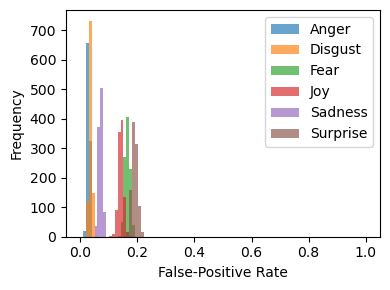

In [88]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(1,1,1)

fpr_df = pd.DataFrame(all_fprs)
fpr_df.columns = [c.title() for c in fpr_df.columns]
sortc = sorted(fpr_df.columns)
fpr_df[sortc].plot.hist(bins=np.linspace(0,1,100), alpha=0.67, ax=ax)
ax.set_xlabel("False-Positive Rate")

plt.tight_layout()
plt.savefig("fp_rate.emotion6.pdf", format="pdf")

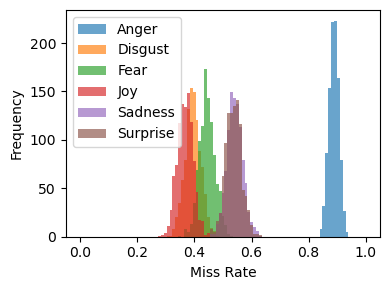

In [89]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(1,1,1)

mr_df = pd.DataFrame(all_mrs)
mr_df.columns = [c.title() for c in mr_df.columns]
sortc = sorted(mr_df.columns)
mr_df[sortc].plot.hist(bins=np.linspace(0,1,100), alpha=0.67, ax=ax)
ax.set_xlabel("Miss Rate")

plt.tight_layout()
plt.savefig("miss_rate.emotion6.pdf", format="pdf")

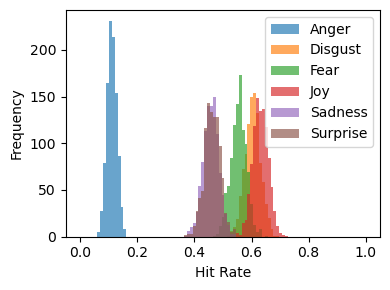

In [90]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(1,1,1)

hr_df = pd.DataFrame(all_hrs)
hr_df.columns = [c.title() for c in hr_df.columns]
sortc = sorted(hr_df.columns)
hr_df[sortc].plot.hist(bins=np.linspace(0,1,100), alpha=0.67, ax=ax)
ax.set_xlabel("Hit Rate")

plt.tight_layout()
plt.savefig("hit_rate.emotion6.pdf", format="pdf")

Surprise: 0.4063, 0.4625, 0.5170
Disgust: 0.5506, 0.6047, 0.6601
Fear: 0.5028, 0.5555, 0.6086
Sadness: 0.4024, 0.4579, 0.5112
Anger: 0.0779, 0.1113, 0.1456
Joy: 0.5785, 0.6321, 0.6845


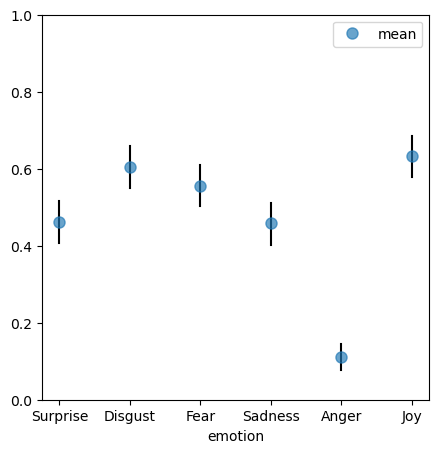

In [91]:
rows = []
for c_ in e_cs:
    c = c_.title()
    low_i = int(hr_df.shape[0] * 0.025)
    hi_i = int(hr_df.shape[0] * 0.975)
    sorted_df = hr_df.sort_values(by=c)
    l_mean = sorted_df[c].mean()
    ci_l = sorted_df[c].values[low_i]
    ci_h = sorted_df[c].values[hi_i]
    print("%s: %0.4f, %0.4f, %0.4f" % (c, ci_l, l_mean, ci_h))

    rows.append((c, ci_l, l_mean, ci_h))
metrcis_df = pd.DataFrame(rows, columns=["emotion", "ci_l", "mean", "ci_h"])

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.set_ylim((0,1))
for idx,row in metrcis_df.iterrows():
    ax.plot([row["emotion"], row["emotion"]], [row["ci_l"], row["ci_h"]], color="black")
metrcis_df.plot(x="emotion", y="mean", linestyle='', marker="o", markersize=8, ax=ax, alpha=0.67)
plt.show()

Surprise: 0.4835, 0.5375, 0.5941
Disgust: 0.3401, 0.3953, 0.4502
Fear: 0.3917, 0.4445, 0.4984
Sadness: 0.4893, 0.5421, 0.5980
Anger: 0.8545, 0.8887, 0.9224
Joy: 0.3166, 0.3679, 0.4224


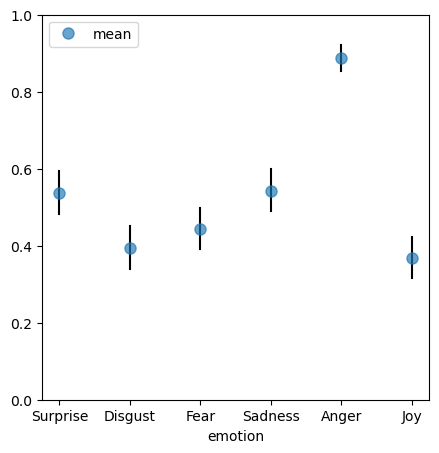

In [92]:
rows = []
for c_ in e_cs:
    c = c_.title()
    low_i = int(hr_df.shape[0] * 0.025)
    hi_i = int(hr_df.shape[0] * 0.975)
    sorted_df = mr_df.sort_values(by=c)
    l_mean = sorted_df[c].mean()
    ci_l = sorted_df[c].values[low_i]
    ci_h = sorted_df[c].values[hi_i]
    print("%s: %0.4f, %0.4f, %0.4f" % (c, ci_l, l_mean, ci_h))

    rows.append((c, ci_l, l_mean, ci_h))
metrcis_df = pd.DataFrame(rows, columns=["emotion", "ci_l", "mean", "ci_h"])

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.set_ylim((0,1))
for idx,row in metrcis_df.iterrows():
    ax.plot([row["emotion"], row["emotion"]], [row["ci_l"], row["ci_h"]], color="black")
metrcis_df.plot(x="emotion", y="mean", linestyle='', marker="o", markersize=8, ax=ax, alpha=0.67)
plt.show()

Surprise: 0.1727, 0.1908, 0.2107
Disgust: 0.0267, 0.0357, 0.0449
Fear: 0.1478, 0.1659, 0.1835
Sadness: 0.0598, 0.0720, 0.0845
Anger: 0.0207, 0.0283, 0.0365
Joy: 0.1255, 0.1424, 0.1596


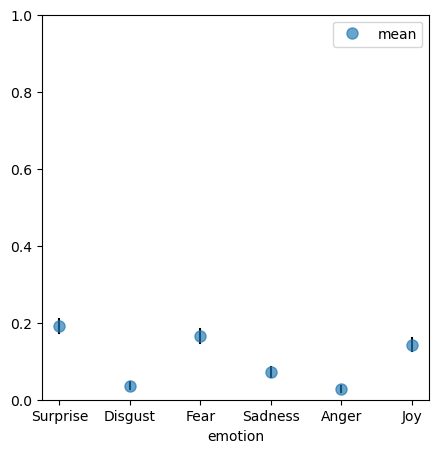

In [93]:
rows = []
for c_ in e_cs:
    c = c_.title()
    low_i = int(fpr_df.shape[0] * 0.025)
    hi_i = int(fpr_df.shape[0] * 0.975)
    sorted_df = fpr_df.sort_values(by=c)
    l_mean = sorted_df[c].mean()
    ci_l = sorted_df[c].values[low_i]
    ci_h = sorted_df[c].values[hi_i]
    print("%s: %0.4f, %0.4f, %0.4f" % (c, ci_l, l_mean, ci_h))

    rows.append((c, ci_l, l_mean, ci_h))
metrcis_df = pd.DataFrame(rows, columns=["emotion", "ci_l", "mean", "ci_h"])

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.set_ylim((0,1))
for idx,row in metrcis_df.iterrows():
    ax.plot([row["emotion"], row["emotion"]], [row["ci_l"], row["ci_h"]], color="black")
metrcis_df.plot(x="emotion", y="mean", linestyle='', marker="o", markersize=8, ax=ax, alpha=0.67)
plt.show()

In [94]:
# Bootstrap the sample
all_g_mrs = []
for i in range(1000):
    bt_df = df.sample(frac=1, replace=True)

    local_mr = {}
    for group_name in {"NEGATIVE", "POSITIVE", "AMBIGUOUS"}:
        local_df = bt_df[bt_df["txt_label_group"] == group_name]
        ma_fprs = []
        for pl in inv_pos_neg_groups[group_name]:
            group = bt_df[bt_df["txt_label_aligned"] == pl]
            miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
            ma_fprs.append(miss_rate)
    
        local_mr[group_name] = np.mean(ma_fprs)

    all_g_mrs.append(local_mr)

Text(0.5, 0, 'Miss Rate')

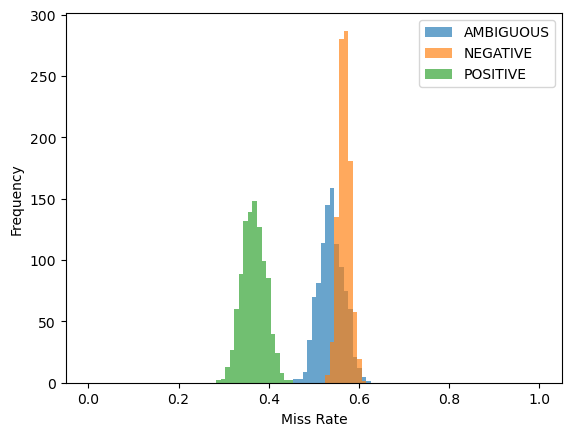

In [95]:
hr_df = pd.DataFrame(all_g_mrs)
hr_df.plot.hist(bins=np.linspace(0,1,100), alpha=0.67)
plt.xlabel("Miss Rate")